Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import sys
import os

In [2]:
IN_COLAB = "google.colab" in sys.modules

if IN_COLAB:
    from google.colab import drive
    drive.mount("/content/drive", force_remount=False)

    REPO_ROOT = Path("/content/drive/Shareddrives/CMPE 295A_B/azure")
    AZURE_RAW_DIR = REPO_ROOT / "2021Dataset"
    DATA_PROCESSED = REPO_ROOT / "processed"
    REPORTS_EVAL = REPO_ROOT / "reports" / "eval" / "resource-central"

else:
    REPO_ROOT = Path.cwd()
    while REPO_ROOT.name != "masters-project" and REPO_ROOT.parent != REPO_ROOT:
        REPO_ROOT = REPO_ROOT.parent

    if REPO_ROOT.name != "masters-project":
        raise RuntimeError("Could not find repo root folder named 'masters-project'.")

    DATA_RAW = REPO_ROOT / "data" / "raw"
    DATA_PROCESSED = REPO_ROOT / "data" / "processed"
    AZURE_RAW_DIR = DATA_RAW / "azure" / "2021Dataset"
    REPORTS_EVAL = REPO_ROOT / "reports" / "eval" / "resource-central"

# Common paths 
FIG_DIR = REPORTS_EVAL / "figures"
TABLE_DIR = REPORTS_EVAL / "tables"
CACHE_DIR = REPORTS_EVAL / "cache"
LOG_DIR = REPORTS_EVAL / "logs"

# Create folders
for p in [AZURE_RAW_DIR, DATA_PROCESSED, FIG_DIR, TABLE_DIR, CACHE_DIR, LOG_DIR]:
    p.mkdir(parents=True, exist_ok=True)

# Input paths
VMTABLE_PATH = AZURE_RAW_DIR / "vmtable.csv.gz"
DEPLOYMENT_PATH = AZURE_RAW_DIR / "deployment.csv.gz"
SUBSCRIPTIONS_PATH = AZURE_RAW_DIR / "subscriptions.csv.gz"
CPU_FILE_PATH = AZURE_RAW_DIR / "vm_cpu_readings-file-1-of-125.csv.gz"

# Output paths
PER_VM_SUMMARY_PATH = DATA_PROCESSED / "resource_central_per_vm_summary.parquet"
BUCKET_METRICS_PATH = TABLE_DIR / "resource_central_bucket_metrics.csv"
VM_LEVEL_RESULTS_PATH = TABLE_DIR / "resource_central_vm_level_results.csv"
BASELINE_METADATA_PATH = TABLE_DIR / "resource_central_baseline_metadata.csv"
CONFUSION_PATH = TABLE_DIR / "resource_central_confusion_matrix.csv"

# Debug prints
print("Repo root:", REPO_ROOT)
print("Running in Colab:", IN_COLAB)
print("Azure raw dir:", AZURE_RAW_DIR)

Repo root: /Users/sofiasilva/Masters-project/masters-project
Running in Colab: False
Azure raw dir: /Users/sofiasilva/Masters-project/masters-project/data/raw/azure/2021Dataset


Dataset

In [ ]:
# Check if dataset exists & required files exist
required_files = [
    "vmtable.csv.gz",
    "deployment.csv.gz",
    "subscriptions.csv.gz",
    "vm_cpu_readings-file-1-of-125.csv.gz"
]

missing_files = [f for f in required_files if not (AZURE_RAW_DIR / f).exists()]

if missing_files:
    print("Missing files:", missing_files)
    print("Download required files below.")
else:
    print("All dataset files already exist.")

# Download Azure dataset + metadata
# Only run once, or rerun if a file is missing.
# Files will be saved into AZURE_RAW_DIR
# Uncomment below if needed:

#!wget -P "{AZURE_RAW_DIR}" https://azurepublicdatasettraces.blob.core.windows.net/azurepublicdataset/trace_data/vm_cpu_readings/vm_cpu_readings-file-1-of-125.csv.gz
#!wget -P "{AZURE_RAW_DIR}" https://azurepublicdatasettraces.blob.core.windows.net/azurepublicdataset/trace_data/vmtable/vmtable.csv.gz
#!wget -P "{AZURE_RAW_DIR}" https://azurepublicdatasettraces.blob.core.windows.net/azurepublicdataset/trace_data/subscriptions/subscriptions.csv.gz
#!wget -P "{AZURE_RAW_DIR}" https://azurepublicdatasettraces.blob.core.windows.net/azurepublicdataset/trace_data/deployment/deployment.csv.gz

Missing files: ['vmtable.csv.gz', 'deployment.csv.gz', 'subscriptions.csv.gz', 'vm_cpu_readings-file-1-of-125.csv.gz']
Download required files below.
--2026-04-10 04:00:41--  https://azurepublicdatasettraces.blob.core.windows.net/azurepublicdataset/trace_data/vm_cpu_readings/vm_cpu_readings-file-1-of-125.csv.gz
Resolving azurepublicdatasettraces.blob.core.windows.net (azurepublicdatasettraces.blob.core.windows.net)... 52.239.236.228
Connecting to azurepublicdatasettraces.blob.core.windows.net (azurepublicdatasettraces.blob.core.windows.net)|52.239.236.228|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 674597280 (643M) [application/octet-stream]
Saving to: ‘/Users/sofiasilva/Masters-project/masters-project/data/raw/azure/2021Dataset/vm_cpu_readings-file-1-of-125.csv.gz’

vm_cpu_readings-fil 100%[===================>] 643.35M  35.4MB/s    in 21s     

2026-04-10 04:01:02 (31.3 MB/s) - ‘/Users/sofiasilva/Masters-project/masters-project/data/raw/azure/2021Dataset

Load Data & Experiment


Dataset shapes:
vmtable: (2013766, 11)
deployment: (35940, 2)
subscriptions: (5957, 3)
cpu: (100000, 5)

vmtable columns:
['x/XsOfHO4ocsV99i4NluqKDuxctW2MMVmwqOPAlg4wp8mqbBOe3wxBlQo0+Qx+uf', 'VDU4C8cqdr+ORcqquwMRcsBA2l0SC6lCPys0wdghKROuxPYysA2XYii9Y5ZkaYaq', 'Pc2VLB8aDxK2DCC96itq4vW/zVDp4wioAUiB3HoGSFYQ0o6/ZCegTpb9vEH4LeMTEWVObHTPRYEY81TYivZCMQ==', '0', '2591700', '99.369869', '3.4240942342446719', '10.194309', 'Delay-insensitive', '1', '1.75']

cpu_df columns:
['timestamp', 'vmId', 'min_cpu', 'max_cpu', 'avg_cpu']

CPU Summary:
       timestamp        min_cpu        max_cpu        avg_cpu
count   100000.0  100000.000000  100000.000000  100000.000000
mean         0.0       4.995654      15.597061       8.620044
std          0.0      11.600477      21.970950      15.170080
min          0.0       0.000000       0.000000       0.000000
25%          0.0       0.683877       3.336821       1.752486
50%          0.0       2.222842       6.955577       3.836173
75%          0.0       4.12122

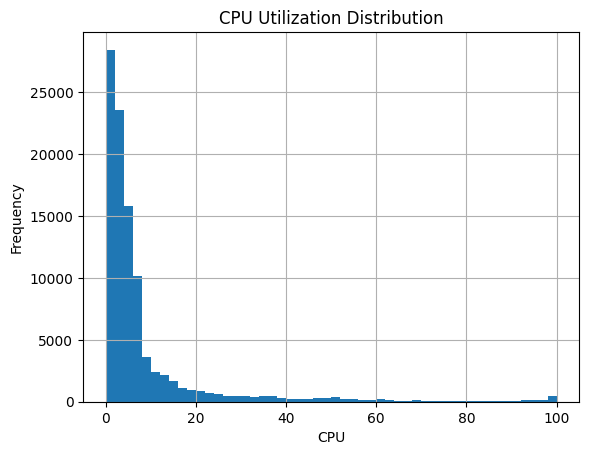


P95 CPU: 38.808594799999995


In [4]:
vmtable_df = pd.read_csv(VMTABLE_PATH, compression="gzip")
deployment_df = pd.read_csv(DEPLOYMENT_PATH, compression="gzip")
subscriptions_df = pd.read_csv(SUBSCRIPTIONS_PATH, compression="gzip")
cpu_df = pd.read_csv(
    CPU_FILE_PATH,
    compression="gzip",
    header=None,
    names=["timestamp", "vmId", "min_cpu", "max_cpu", "avg_cpu"],
    nrows=100000,
)

# Check shapes
print("\nDataset shapes:")
print("vmtable:", vmtable_df.shape)
print("deployment:", deployment_df.shape)
print("subscriptions:", subscriptions_df.shape)
print("cpu:", cpu_df.shape)

# Inspect columns
print("\nvmtable columns:")
print(vmtable_df.columns.tolist())
print("\ncpu_df columns:")
print(cpu_df.columns.tolist())

# Basic CPU stats (first experiment)
print("\nCPU Summary:")
print(cpu_df.describe())

# Plot CPU distribution
cpu_col = "avg_cpu"
cpu_df[cpu_col].hist(bins=50)
plt.title("CPU Utilization Distribution")
plt.xlabel("CPU")
plt.ylabel("Frequency")
plt.show()

# Compute P95
p95 = cpu_df[cpu_col].quantile(0.95)
print("\nP95 CPU:", p95)


In [5]:
# Clean CPU columns
for col in ["min_cpu", "max_cpu", "avg_cpu"]:
    cpu_df[col] = pd.to_numeric(cpu_df[col], errors="coerce")

cpu_df = cpu_df.dropna(subset=["vmId", "avg_cpu", "max_cpu"])
print("Cleaned cpu_df shape:", cpu_df.shape)

# Per-VM summaries
per_vm = (
    cpu_df.groupby("vmId")
    .agg(
        mean_cpu=("avg_cpu", "mean"),
        max_of_max_cpu=("max_cpu", "max"),
        p90_cpu=("max_cpu", lambda x: x.quantile(0.90)),
        p95_cpu=("max_cpu", lambda x: x.quantile(0.95)),
        p99_cpu=("max_cpu", lambda x: x.quantile(0.99)),
        n_samples=("max_cpu", "count"),
        std_cpu=("max_cpu", "std")
    )
    .reset_index()
)

per_vm["std_cpu"] = per_vm["std_cpu"].fillna(0)
per_vm["p95_minus_mean"] = per_vm["p95_cpu"] - per_vm["mean_cpu"]

print("\nPer-VM summary:")
print(per_vm.head())
print("Number of VMs:", len(per_vm))
print("Average P95 - Mean:", per_vm["p95_minus_mean"].mean())
print("Median  P95 - Mean:", per_vm["p95_minus_mean"].median())

per_vm.to_parquet(PER_VM_SUMMARY_PATH, index=False)
print("Saved:", PER_VM_SUMMARY_PATH)

Cleaned cpu_df shape: (100000, 5)

Per-VM summary:
                                                vmId   mean_cpu  \
0  ++/aOQtwAA4f8xfzP3apaH83eUKzb2I1pgteVTb9GXfHWH...  11.135210   
1  ++2TXbBOauRca6XG1ETP31Np19j644frNMdvNhloTTWiFe...   1.679437   
2  ++3x/X632+RBxrMiCXl0hgaM8HbCIz43648D/55jURvl0K...   9.191788   
3  ++6f+PhobyB4y2TT3ZsBulQFjoEBi+xSI8Ax3sT7AkUI/l...   4.744954   
4  ++Emh319MDIxnjd5HCgcf8/EEw4Tbcr0ZcYPCA87xDD9oV...   1.504707   

   max_of_max_cpu    p90_cpu    p95_cpu    p99_cpu  n_samples  std_cpu  \
0       13.075992  13.075992  13.075992  13.075992          1      0.0   
1        3.450097   3.450097   3.450097   3.450097          1      0.0   
2       11.400792  11.400792  11.400792  11.400792          1      0.0   
3        8.083851   8.083851   8.083851   8.083851          1      0.0   
4        5.936317   5.936317   5.936317   5.936317          1      0.0   

   p95_minus_mean  
0        1.940782  
1        1.770660  
2        2.209004  
3        3.338897  
4

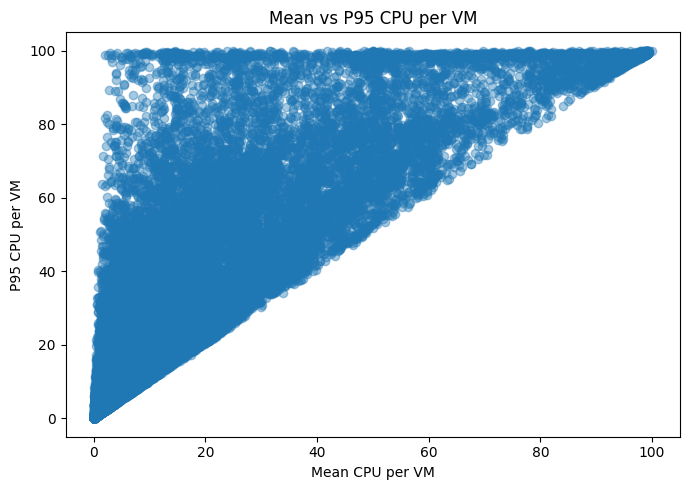

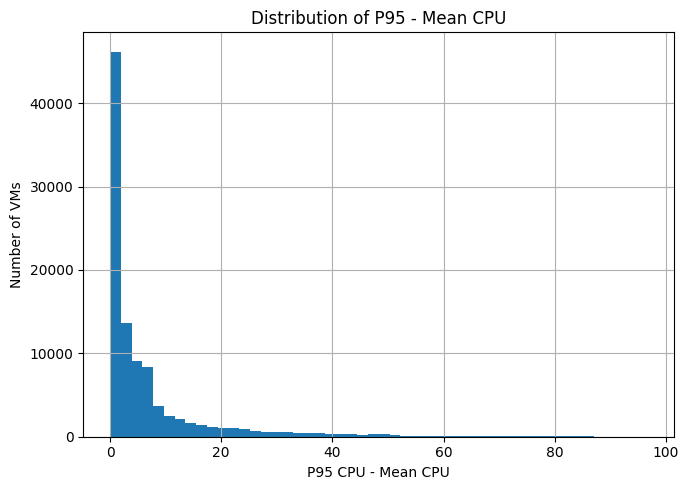

In [6]:
# Plots: mean vs P95
plt.figure(figsize=(7, 5))
plt.scatter(per_vm["mean_cpu"], per_vm["p95_cpu"], alpha=0.4)
plt.xlabel("Mean CPU per VM")
plt.ylabel("P95 CPU per VM")
plt.title("Mean vs P95 CPU per VM")
plt.tight_layout()
plt.savefig(FIG_DIR / "mean_vs_p95_cpu_per_vm.png", dpi=200, bbox_inches="tight")
plt.show()

plt.figure(figsize=(7, 5))
per_vm["p95_minus_mean"].hist(bins=50)
plt.xlabel("P95 CPU - Mean CPU")
plt.ylabel("Number of VMs")
plt.title("Distribution of P95 - Mean CPU")
plt.tight_layout()
plt.savefig(FIG_DIR / "p95_minus_mean_distribution.png", dpi=200, bbox_inches="tight")
plt.show()

In [7]:
# Bucketization
def bucketize(x):
    if x <= 25:
        return "0-25"
    elif x <= 50:
        return "25-50"
    elif x <= 75:
        return "50-75"
    else:
        return "75-100+"

# Detect whether values are 0-1 scale or 0-100 scale
scale_factor = 100 if per_vm["p95_cpu"].max() <= 1.5 else 1
print("Scale factor:", scale_factor)

per_vm["mean_cpu_pct"] = per_vm["mean_cpu"] * scale_factor
per_vm["p95_cpu_pct"] = per_vm["p95_cpu"] * scale_factor

per_vm["mean_bucket"] = per_vm["mean_cpu_pct"].apply(bucketize)
per_vm["p95_bucket"] = per_vm["p95_cpu_pct"].apply(bucketize)

accuracy = (per_vm["mean_bucket"] == per_vm["p95_bucket"]).mean()
print("Bucket accuracy (mean vs p95):", accuracy)

Scale factor: 1
Bucket accuracy (mean vs p95): 0.8711


In [8]:
# Precision / Recall by bucket
buckets = ["0-25", "25-50", "50-75", "75-100+"]

rows = []
for b in buckets:
    tp = ((per_vm["mean_bucket"] == b) & (per_vm["p95_bucket"] == b)).sum()
    fp = ((per_vm["mean_bucket"] == b) & (per_vm["p95_bucket"] != b)).sum()
    fn = ((per_vm["mean_bucket"] != b) & (per_vm["p95_bucket"] == b)).sum()

    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0

    rows.append({
        "bucket": b,
        "precision": precision,
        "recall": recall,
        "support": (per_vm["p95_bucket"] == b).sum()
    })

bucket_metrics_df = pd.DataFrame(rows)

print("\nBucket metrics:")
print(bucket_metrics_df)

print("\nConfusion matrix:")
confusion = pd.crosstab(
    per_vm["p95_bucket"],
    per_vm["mean_bucket"],
    rownames=["Actual (P95 bucket)"],
    colnames=["Predicted (Mean bucket)"]
)
print(confusion)
bucket_metrics_df.to_csv(BUCKET_METRICS_PATH, index=False)
confusion.to_csv(CONFUSION_PATH)
per_vm.to_csv(VM_LEVEL_RESULTS_PATH, index=False)

print("Saved:", BUCKET_METRICS_PATH)
print("Saved:", CONFUSION_PATH)
print("Saved:", VM_LEVEL_RESULTS_PATH)


Bucket metrics:
    bucket  precision    recall  support
0     0-25   0.906580  1.000000    83322
1    25-50   0.348505  0.199823     7932
2    50-75   0.310540  0.146887     4112
3  75-100+   1.000000  0.345058     4634

Confusion matrix:
Predicted (Mean bucket)   0-25  25-50  50-75  75-100+
Actual (P95 bucket)                                  
0-25                     83322      0      0        0
25-50                     6347   1585      0        0
50-75                     1596   1912    604        0
75-100+                    643   1051   1341     1599
Saved: /Users/sofiasilva/Masters-project/masters-project/reports/eval/resource-central/tables/resource_central_bucket_metrics.csv
Saved: /Users/sofiasilva/Masters-project/masters-project/reports/eval/resource-central/tables/resource_central_confusion_matrix.csv
Saved: /Users/sofiasilva/Masters-project/masters-project/reports/eval/resource-central/tables/resource_central_vm_level_results.csv


Results

In [9]:
# Interpret results
avg_diff = per_vm["p95_minus_mean"].mean()
med_diff = per_vm["p95_minus_mean"].median()
acc = accuracy

print("----- Azure Reproduction Summary -----")
print(f"Number of VMs analyzed: {len(per_vm)}")
print(f"Average P95 - Mean CPU: {avg_diff:.4f}")
print(f"Median  P95 - Mean CPU: {med_diff:.4f}")
print(f"Bucket accuracy (Mean vs P95): {acc:.4f}")
print("\nBucket precision/recall:")
print(bucket_metrics_df)

----- Azure Reproduction Summary -----
Number of VMs analyzed: 100000
Average P95 - Mean CPU: 6.9770
Median  P95 - Mean CPU: 2.2952
Bucket accuracy (Mean vs P95): 0.8711

Bucket precision/recall:
    bucket  precision    recall  support
0     0-25   0.906580  1.000000    83322
1    25-50   0.348505  0.199823     7932
2    50-75   0.310540  0.146887     4112
3  75-100+   1.000000  0.345058     4634


Per-VM Summary

In [10]:
display(per_vm.head())

,vmId,mean_cpu,max_of_max_cpu,p90_cpu,p95_cpu,p99_cpu,n_samples,std_cpu,p95_minus_mean,mean_cpu_pct,p95_cpu_pct,mean_bucket,p95_bucket
0,++/aOQtwAA4f8xfzP3apaH83eUKzb2I1pgteVTb9GXfHWH...,11.135210,13.075992,13.075992,13.075992,13.075992,1,0.0,1.940782,11.135210,13.075992,0-25,0-25
1,++2TXbBOauRca6XG1ETP31Np19j644frNMdvNhloTTWiFe...,1.679437,3.450097,3.450097,3.450097,3.450097,1,0.0,1.770660,1.679437,3.450097,0-25,0-25
2,++3x/X632+RBxrMiCXl0hgaM8HbCIz43648D/55jURvl0K...,9.191788,11.400792,11.400792,11.400792,11.400792,1,0.0,2.209004,9.191788,11.400792,0-25,0-25
3,++6f+PhobyB4y2TT3ZsBulQFjoEBi+xSI8Ax3sT7AkUI/l...,4.744954,8.083851,8.083851,8.083851,8.083851,1,0.0,3.338897,4.744954,8.083851,0-25,0-25
4,++Emh319MDIxnjd5HCgcf8/EEw4Tbcr0ZcYPCA87xDD9oV...,1.504707,5.936317,5.936317,5.936317,5.936317,1,0.0,4.431610,1.504707,5.936317,0-25,0-25


 Bucket Metrics (Precision, Recall, Support)

In [11]:
display(bucket_metrics_df)

,bucket,precision,recall,support
0,0-25,0.906580,1.000000,83322
1,25-50,0.348505,0.199823,7932
2,50-75,0.310540,0.146887,4112
3,75-100+,1.000000,0.345058,4634


Confusion Matrix (Actual P95 Bucket vs. Predicted Mean Bucket)

In [12]:
display(confusion)

Predicted (Mean bucket),0-25,25-50,50-75,75-100+
Actual (P95 bucket),,,,
0-25,83322,0,0,0
25-50,6347,1585,0,0
50-75,1596,1912,604,0
75-100+,643,1051,1341,1599


Metadata Summary

In [13]:
metadata = pd.DataFrame([
    {
        "notebook": "resource_central.ipynb",
        "dataset_dir": str(AZURE_RAW_DIR),
        "vmtable_path": str(VMTABLE_PATH),
        "deployment_path": str(DEPLOYMENT_PATH),
        "subscriptions_path": str(SUBSCRIPTIONS_PATH),
        "cpu_file_path": str(CPU_FILE_PATH),
        "cpu_rows_loaded": len(cpu_df),
        "n_vms": len(per_vm),
        "pct_conversion_factor": scale_factor,
        "avg_p95_minus_mean": per_vm["p95_minus_mean"].mean(),
        "median_p95_minus_mean": per_vm["p95_minus_mean"].median(),
        "bucket_accuracy": accuracy,
        "per_vm_summary_path": str(PER_VM_SUMMARY_PATH),
        "bucket_metrics_path": str(BUCKET_METRICS_PATH),
        "vm_level_results_path": str(VM_LEVEL_RESULTS_PATH),
        "confusion_matrix_path": str(CONFUSION_PATH),
    }
])

metadata.to_csv(BASELINE_METADATA_PATH, index=False)
print("Saved:", BASELINE_METADATA_PATH)
display(metadata)

Saved: /Users/sofiasilva/Masters-project/masters-project/reports/eval/resource-central/tables/resource_central_baseline_metadata.csv


,notebook,dataset_dir,vmtable_path,deployment_path,subscriptions_path,cpu_file_path,cpu_rows_loaded,n_vms,pct_conversion_factor,avg_p95_minus_mean,median_p95_minus_mean,bucket_accuracy,per_vm_summary_path,bucket_metrics_path,vm_level_results_path,confusion_matrix_path
0,resource_central.ipynb,/Users/sofiasilva/Masters-project/masters-proj...,/Users/sofiasilva/Masters-project/masters-proj...,/Users/sofiasilva/Masters-project/masters-proj...,/Users/sofiasilva/Masters-project/masters-proj...,/Users/sofiasilva/Masters-project/masters-proj...,100000,100000,1,6.977017,2.295213,0.8711,/Users/sofiasilva/Masters-project/masters-proj...,/Users/sofiasilva/Masters-project/masters-proj...,/Users/sofiasilva/Masters-project/masters-proj...,/Users/sofiasilva/Masters-project/masters-proj...
